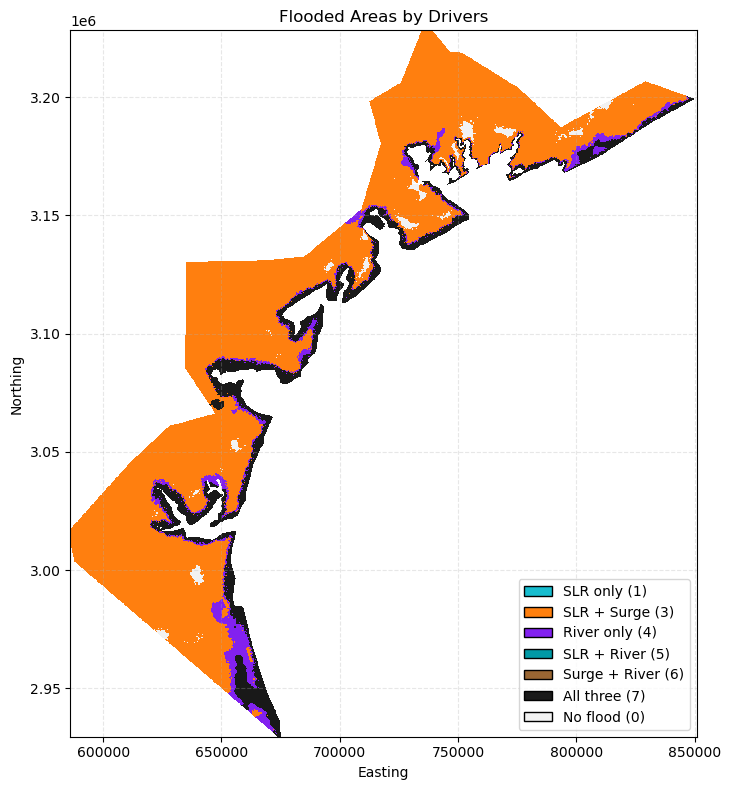

In [10]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ------------------- INPUTS -------------------
r_surge = r"D:\Phd Research\inundation depth 100 yr surge only.tif"
r_slr   = r"D:\Phd Research\inundation depth only SLR.tif"
r_river = r"D:\Phd Research\inundation depth 100 yr river flow.tif"

THRESHOLD = 0.10   # meters: flooded if depth > THRESHOLD
# ----------------------------------------------

def read_band(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        profile = src.profile
    if nodata is not None:
        mask = (arr != nodata) & np.isfinite(arr)
        arr = np.where(mask, arr, np.nan)
    else:
        arr = np.where(np.isfinite(arr), arr, np.nan)
    return arr, profile

# 1) Read the three rasters
surge_arr, surge_prof = read_band(r_surge)
slr_arr,   slr_prof   = read_band(r_slr)
river_arr, river_prof = read_band(r_river)

# 2) Reproject SLR and River to SURGE grid (shape, transform, CRS)
dst_shape     = (surge_prof["height"], surge_prof["width"])
dst_transform = surge_prof["transform"]
dst_crs       = surge_prof["crs"]

def reproject_to_ref(src_arr, src_prof, dst_shape, dst_transform, dst_crs):
    dst = np.full(dst_shape, np.nan, dtype=float)
    reproject(
        source=src_arr,
        destination=dst,
        src_transform=src_prof["transform"],
        src_crs=src_prof["crs"],
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    return dst

slr_r = slr_arr if (slr_prof["crs"] == dst_crs and
                    slr_arr.shape == surge_arr.shape and
                    slr_prof["transform"] == dst_transform) else \
        reproject_to_ref(slr_arr, slr_prof, dst_shape, dst_transform, dst_crs)

river_r = river_arr if (river_prof["crs"] == dst_crs and
                        river_arr.shape == surge_arr.shape and
                        river_prof["transform"] == dst_transform) else \
          reproject_to_ref(river_arr, river_prof, dst_shape, dst_transform, dst_crs)

# 3) Build flooded masks (> THRESHOLD)
slr_flood   = np.where(slr_r   > THRESHOLD, 1, 0)
surge_flood = np.where(surge_arr > THRESHOLD, 1, 0)
river_flood = np.where(river_r > THRESHOLD, 1, 0)

# 4) Categorical code via bitmask: SLR=1, SURGE=2, RIVER=4
#    Values 0..7 encode all combinations
cat = (slr_flood * 1) + (surge_flood * 2) + (river_flood * 4)

# Optional: mask out pixels where *all three* are NaN in original data
all_nan = np.isnan(slr_r) & np.isnan(surge_arr) & np.isnan(river_r)
cat = np.where(all_nan, -1, cat)  # -1 = outside / nodata

# 5) Colormap (index-based)
#    -1 nodata (transparent), 0 none, 1 SLR, 2 Surge, 3 SLR+Surge,
#     4 River, 5 SLR+River, 6 Surge+River, 7 All three
cmap_list = [
    (0,0,0,0),      # -1 (transparent)
    (0.95, 0.95, 0.95, 1.0),  # 0 none (light gray) - you can set to fully transparent if you prefer
    (0.09, 0.74, 0.81, 1.0),  # 1 SLR (teal)      # "#17becf"
    (1.00, 0.50, 0.06, 1.0),  # 2 Surge (orange)  # "#ff7f0e"
    (0.51, 0.13, 0.94, 1.0),  # 3 SLR+Surge (purple)
    (0.10, 0.65, 0.35, 1.0),  # 4 River (green)
    (0.00, 0.60, 0.65, 1.0),  # 5 SLR+River (blue-green)
    (0.60, 0.40, 0.20, 1.0),  # 6 Surge+River (brown)
    (0.10, 0.10, 0.10, 1.0),  # 7 All three (black)
]
# Build a ListedColormap aligned to indices [-1..7] -> shift by +1
cmap = ListedColormap(cmap_list)

# 6) Plot
fig, ax = plt.subplots(figsize=(10, 8))

# extent from reference (surge) GeoTransform
left = dst_transform.c
top = dst_transform.f
px_w = dst_transform.a
px_h = dst_transform.e  # negative
width = surge_prof["width"]
height = surge_prof["height"]
right = left + px_w * width
bottom = top + px_h * height  # px_h is negative

im = ax.imshow(cat + 1,  # shift so -1 -> 0 index in cmap
               cmap=cmap,
               interpolation='nearest',
               extent=[left, right, bottom, top],
               origin='upper')

ax.set_title("Flooded Areas by Drivers")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect('equal')

# Legend (show only the classes you want)
legend_elems = [
    Patch(facecolor=cmap_list[2], edgecolor='k', label='SLR only'),
    Patch(facecolor=cmap_list[3], edgecolor='k', label='SLR + Surge'),
    Patch(facecolor=cmap_list[4], edgecolor='k', label='River only'),
    Patch(facecolor=cmap_list[6], edgecolor='k', label='SLR + River'),
    Patch(facecolor=cmap_list[3], edgecolor='k', label='SLR + Surge'), # already included above
    Patch(facecolor=cmap_list[7], edgecolor='k', label='Surge + River'),
    Patch(facecolor=cmap_list[8], edgecolor='k', label='All three'),
    Patch(facecolor=cmap_list[1], edgecolor='k', label='No flood'),
]
# Build in desired order (redefine for clarity)
legend_elems = [
    Patch(facecolor=cmap_list[2], edgecolor='k', label='SLR only (1)'),
    Patch(facecolor=cmap_list[3], edgecolor='k', label='SLR + Surge (3)'),
    Patch(facecolor=cmap_list[4], edgecolor='k', label='River only (4)'),
    Patch(facecolor=cmap_list[6], edgecolor='k', label='SLR + River (5)'),
    Patch(facecolor=cmap_list[7], edgecolor='k', label='Surge + River (6)'),
    Patch(facecolor=cmap_list[8], edgecolor='k', label='All three (7)'),
    Patch(facecolor=cmap_list[1], edgecolor='k', label='No flood (0)'),
]

ax.legend(handles=legend_elems, loc='lower right', frameon=True)

ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# ------------------ OPTIONAL ------------------
# If you want ONLY the three exclusive categories (SLR-only, Surge-only, River-only) on the map:
# exc = np.full_like(cat, -1)
# exc[(cat == 1)] = 1   # SLR only
# exc[(cat == 2)] = 2   # Surge only
# exc[(cat == 4)] = 4   # River only
# Then plot 'exc' with a 4-color cmap (transparent + three colors) and a shorter legend.


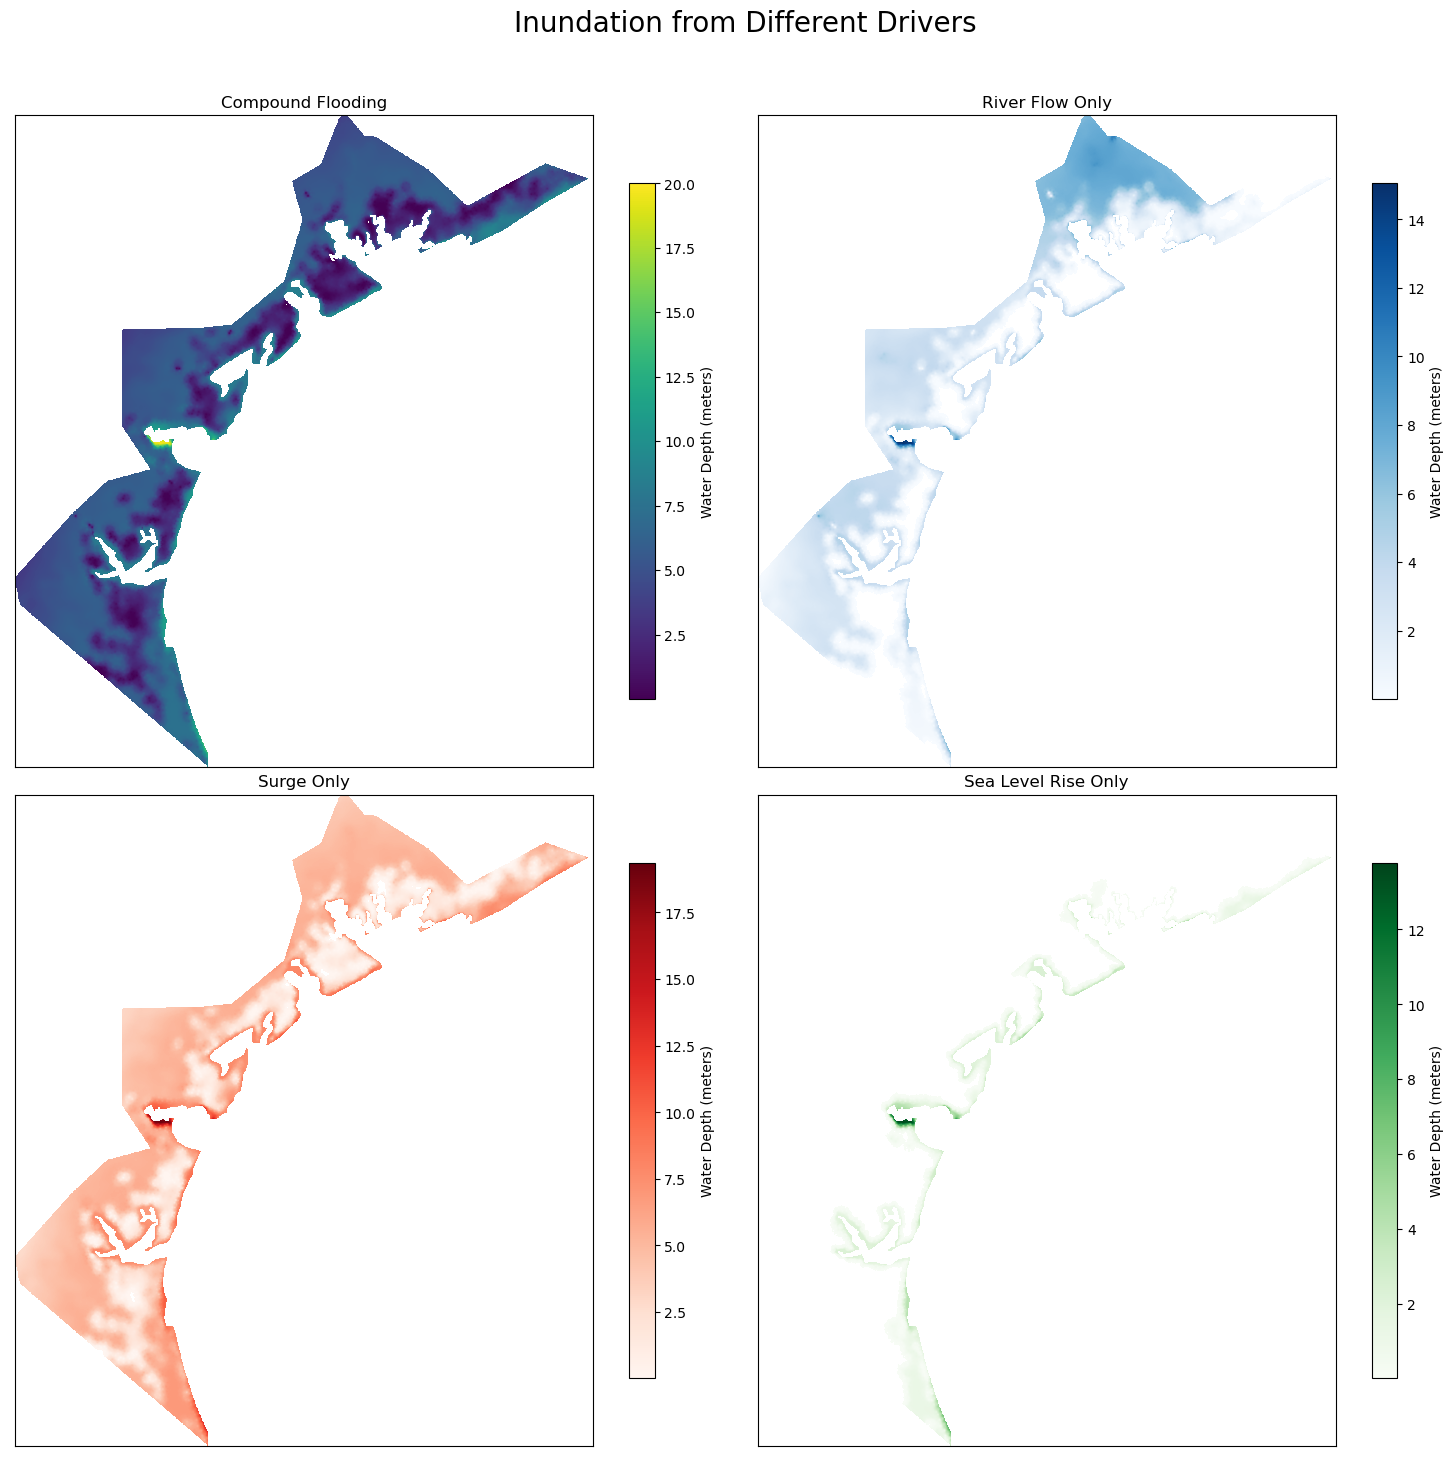

In [55]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import numpy as np

# A list of tuples containing the file paths and their corresponding labels and colormaps.
# NOTE: Replace the paths with the actual paths to your TIFF files.
inundation_data = [
    (r"D:\Phd Research\sim_depth_100yr.tif", "Compound Flooding", "viridis"),
    (r"D:\Phd Research\inundation depth riverflow 100 yr only new ver5.tif", "River Flow Only", "Blues"),
    (r"D:\Phd Research\inundation depth 100 yr surge only.tif", "Surge Only", "Reds"),
    (r"D:\Phd Research\inundation depth only SLR.tif", "Sea Level Rise Only", "Greens")
]

# Set up the subplot layout for the four plots.
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()
fig.suptitle('Inundation from Different Drivers', fontsize=20)

for i, (path, title, cmap_name) in enumerate(inundation_data):
    try:
        # Open the raster file.
        with rasterio.open(path) as src:
            # Read the raster data.
            data = src.read(1)

            # Replace NoData values with 0 for consistent plotting.
            if src.nodata is not None:
                data[data == src.nodata] = 0

            # Get a colormap and set NoData values (where depth is 0) to transparent.
            cmap = plt.get_cmap(cmap_name)
            cmap.set_under('white', alpha=0)  # Make areas with zero depth transparent.

            # Plot the data on the corresponding subplot.
            im = axes[i].imshow(data, cmap=cmap, vmin=0.01) # Set vmin to a small value to hide 0s.
            axes[i].set_title(title)
            axes[i].set_xticks([])
            axes[i].set_yticks([])

            # Add a colorbar for each plot.
            cbar = fig.colorbar(im, ax=axes[i], orientation='vertical', shrink=0.75)
            cbar.set_label('Water Depth (meters)')

    except rasterio.errors.RasterioIOError:
        axes[i].set_title(f"Error: Could not open {title} file")
        axes[i].text(0.5, 0.5, "File not found", ha='center', va='center', transform=axes[i].transAxes)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('inundation_plot.png')
plt.show() # Use plt.show() to display the plot directly

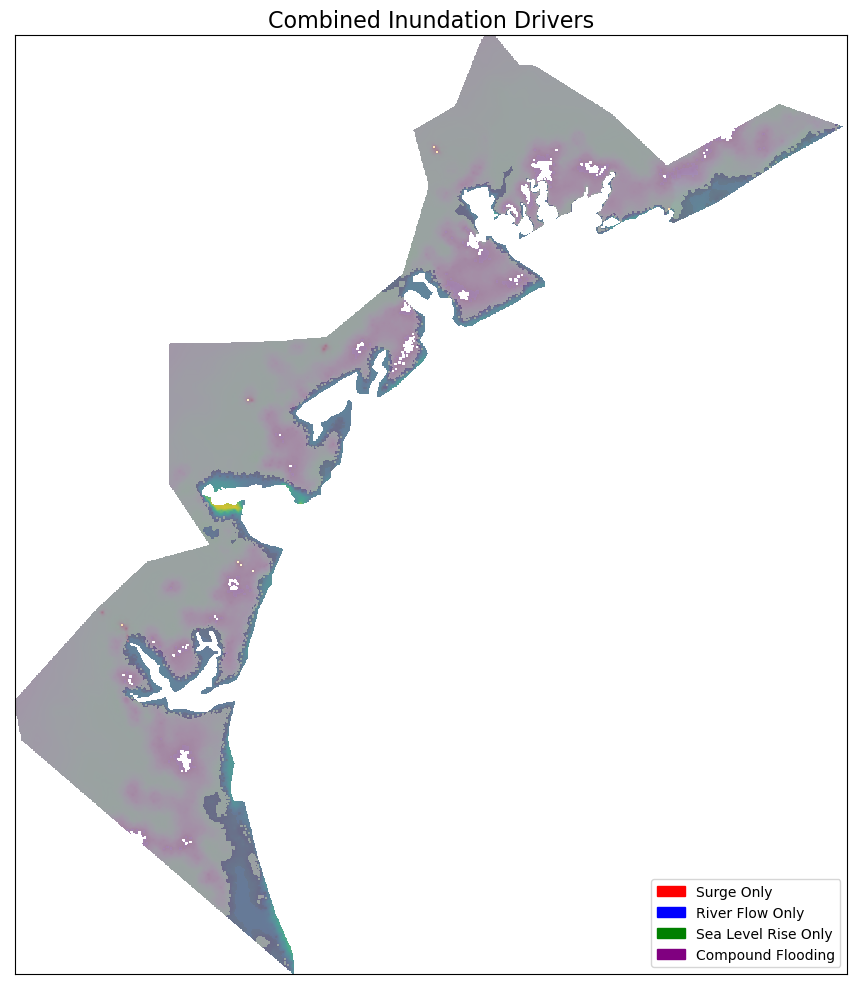

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.plot import show
import numpy as np

# A list of tuples containing the file paths, labels, and colors for each layer.
# NOTE: Replace the paths with the actual paths to your TIFF files.
inundation_data = [
    # Plot larger, more encompassing datasets first for better visibility of overlaps.
    (r"D:\Phd Research\inundation depth 100 yr surge only.tif", "Surge Only", "red"),
    (r"D:\Phd Research\inundation depth 100 yr river flow.tif", "River Flow Only", "blue"),
    (r"D:\Phd Research\inundation depth only SLR.tif", "Sea Level Rise Only", "green"),
    (r"D:\Phd Research\sim_depth_100yr.tif", "Compound Flooding", "purple") # This is a good layer to plot last
]

# Create a single figure and axes.
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title('Combined Inundation Drivers', fontsize=16)

# Create custom legend handles.
legend_handles = []

for path, label, color in inundation_data:
    try:
        with rasterio.open(path) as src:
            # Read the raster data.
            data = src.read(1)

            # Mask out non-inundated areas.
            # We'll plot only values greater than a very small threshold (e.g., 0.1) to hide non-water areas.
            data[data < 0.1] = np.nan

            # Plot the data on the same axes with transparency.
            im = ax.imshow(data, cmap=plt.cm.get_cmap('YlOrRd' if 'surge' in label.lower() else 'Blues' if 'river' in label.lower() else 'Greens' if 'slr' in label.lower() else 'viridis'),
                           alpha=0.5,
                           extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top])

            # Create a patch for the legend with the specified color and label.
            legend_handles.append(mpatches.Patch(color=color, label=label))

    except rasterio.errors.RasterioIOError:
        print(f"Error: Could not open {label} file at {path}")

# Turn off axis ticks and labels for a cleaner map view.
ax.set_xticks([])
ax.set_yticks([])

# Add the legend to the plot.
ax.legend(handles=legend_handles, loc='lower right')

# Use tight_layout to ensure everything fits without overlapping.
plt.tight_layout()
plt.savefig('combined_inundation_plot.png')
plt.show() # Use plt.show() to display the plot directly

Plot saved as 'inundation_overlap_map.png'


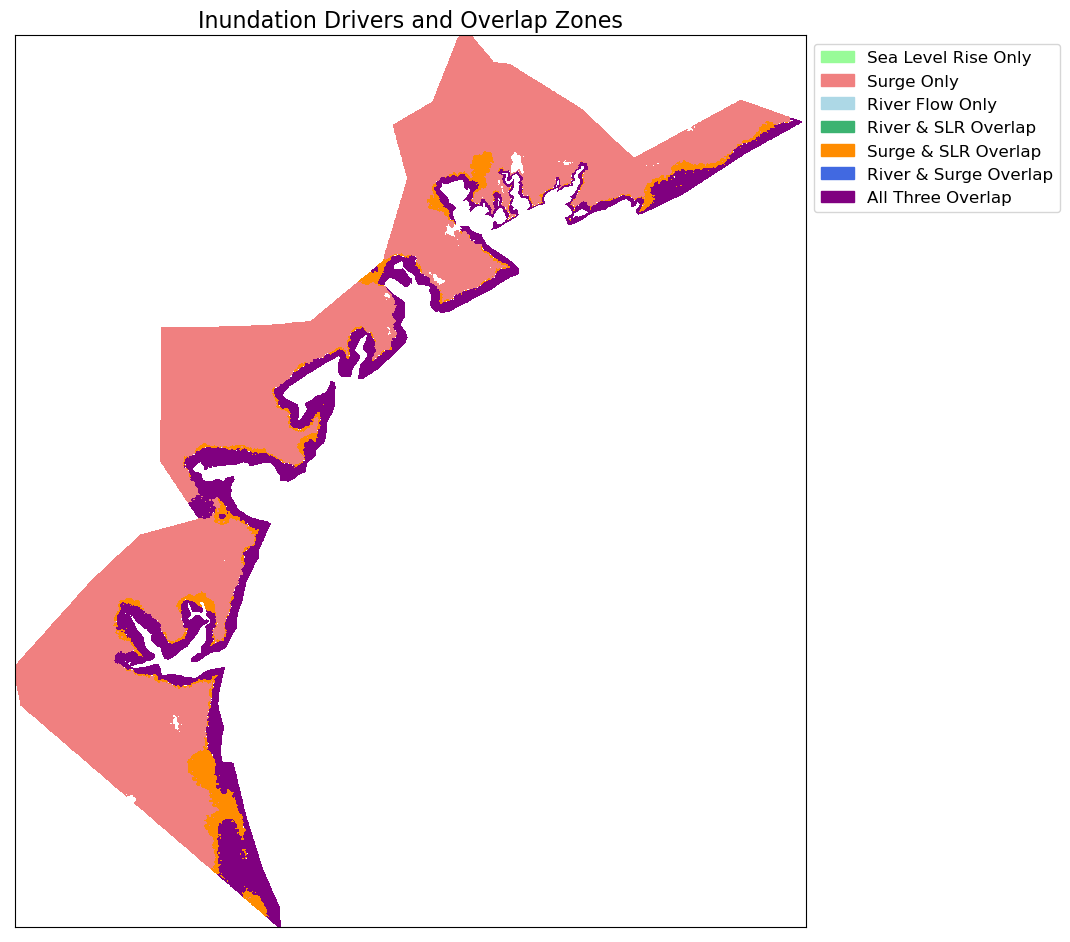

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
import numpy as np
from matplotlib.colors import ListedColormap

# --- 1. Define File Paths and Labels ---
# NOTE: Replace the paths with the actual paths to your TIFF files.
file_paths = {
    'river': r"D:\Phd Research\inundation depth 100 yr river flow.tif",
    'surge': r"D:\Phd Research\inundation depth 100 yr surge only.tif",
    'slr': r"D:\Phd Research\inundation depth only SLR.tif"
}

# --- 2. Load the Raster Data ---
try:
    with rasterio.open(file_paths['river']) as src_river:
        river_data = src_river.read(1)
        transform = src_river.transform
        bounds = src_river.bounds
        nodata = src_river.nodata
        
    with rasterio.open(file_paths['surge']) as src_surge:
        surge_data = src_surge.read(1)

    with rasterio.open(file_paths['slr']) as src_slr:
        slr_data = src_slr.read(1)
        
except rasterio.errors.RasterioIOError as e:
    print(f"Error: Could not open one or more raster files. Please check the paths. Details: {e}")
    exit()

# Set NoData values to 0 for calculations
if nodata is not None:
    river_data[river_data == nodata] = 0
    surge_data[surge_data == nodata] = 0
    slr_data[slr_data == nodata] = 0

# Set a small threshold to consider "inundated"
threshold = 0.01

# --- 3. Perform Boolean Raster Calculations for Overlap Areas ---
river_only = (river_data > threshold) & (surge_data < threshold) & (slr_data < threshold)
surge_only = (surge_data > threshold) & (river_data < threshold) & (slr_data < threshold)
slr_only = (slr_data > threshold) & (river_data < threshold) & (surge_data < threshold)

river_and_surge = (river_data > threshold) & (surge_data > threshold) & (slr_data < threshold)
river_and_slr = (river_data > threshold) & (slr_data > threshold) & (surge_data < threshold)
surge_and_slr = (surge_data > threshold) & (slr_data > threshold) & (river_data < threshold)

all_three = (river_data > threshold) & (surge_data > threshold) & (slr_data > threshold)

# --- 4. Define Plotting Layers and Colors ---
plot_layers = [
    (slr_only, 'Sea Level Rise Only', 'palegreen'),
    (surge_only, 'Surge Only', 'lightcoral'),
    (river_only, 'River Flow Only', 'lightblue'),
    (river_and_slr, 'River & SLR Overlap', 'mediumseagreen'),
    (surge_and_slr, 'Surge & SLR Overlap', 'darkorange'),
    (river_and_surge, 'River & Surge Overlap', 'royalblue'),
    (all_three, 'All Three Overlap', 'purple')
]

# --- 5. Create and Plot the Map ---
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_title('Inundation Drivers and Overlap Zones', fontsize=16)

# Create a list for legend patches
legend_patches = []

for data, label, color in plot_layers:
    # Use ListedColormap to create a single-color colormap for plotting the boolean mask.
    # The first color is transparent, the second is the desired color.
    single_color_cmap = ListedColormap(['none', color])
    
    # Use imshow with the new single-color colormap.
    ax.imshow(data, cmap=single_color_cmap,
              extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
    
    # Create a patch for the legend
    legend_patches.append(mpatches.Patch(color=color, label=label))

# Turn off axis ticks for a cleaner map view
ax.set_xticks([])
ax.set_yticks([])

# Add the custom legend
ax.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)

# Adjust plot layout and save the figure
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('inundation_overlap_map.png', dpi=300)
print("Plot saved as 'inundation_overlap_map.png'")
plt.show()

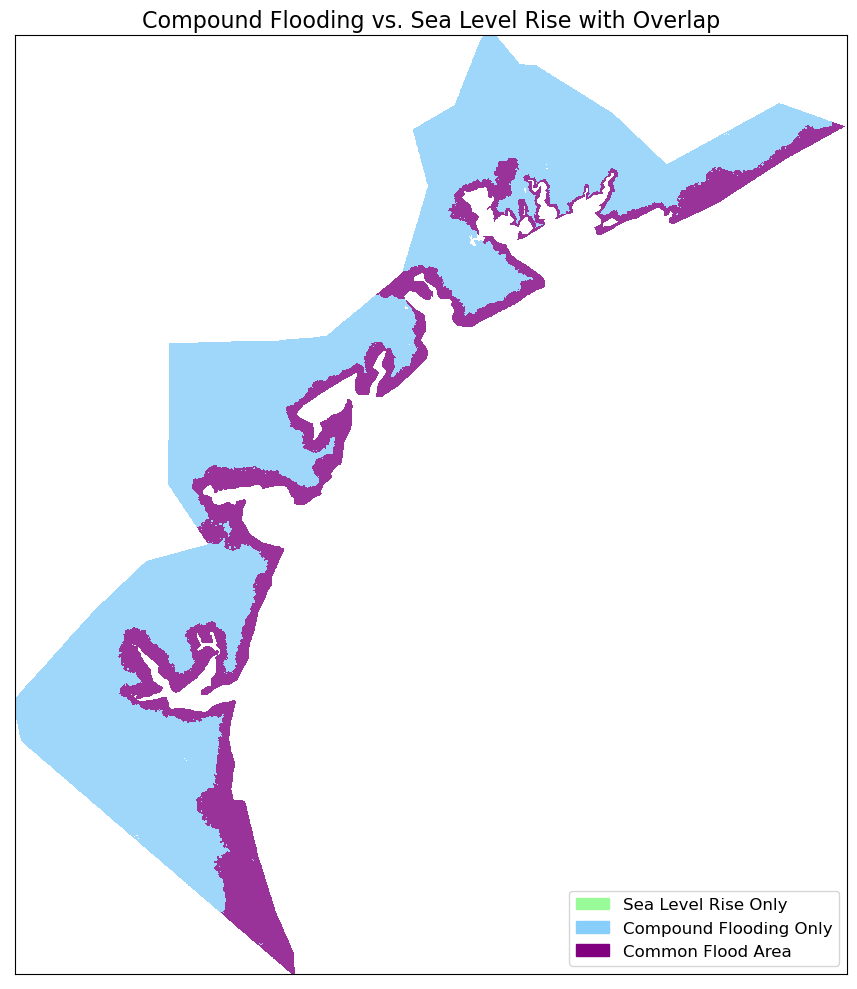

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
import numpy as np
from matplotlib.colors import ListedColormap

# --- 1. Define File Paths and Labels ---
# NOTE: Replace the paths with the actual paths to your TIFF files.
file_paths = {
    'compound': r"D:\Phd Research\sim_depth_100yr.tif",
    'slr': r"D:\Phd Research\inundation depth only SLR.tif"
}

# --- 2. Load the Raster Data ---
try:
    with rasterio.open(file_paths['compound']) as src_compound:
        compound_data = src_compound.read(1)
        transform = src_compound.transform
        bounds = src_compound.bounds
        nodata = src_compound.nodata
        
    with rasterio.open(file_paths['slr']) as src_slr:
        slr_data = src_slr.read(1)
        
except rasterio.errors.RasterioIOError as e:
    print(f"Error: Could not open one or both raster files. Please check the paths. Details: {e}")
    exit()

# Set NoData values to 0
if nodata is not None:
    compound_data[compound_data == nodata] = 0
    slr_data[slr_data == nodata] = 0

# Set a small threshold to consider "inundated"
threshold = 0.01

# --- 3. Perform Boolean Raster Calculations for Individual and Overlap Areas ---
slr_only = (slr_data > threshold) & (compound_data < threshold)
compound_only = (compound_data > threshold) & (slr_data < threshold)
common_flood_area = (slr_data > threshold) & (compound_data > threshold)

# --- 4. Define Plotting Layers and Colors ---
plot_layers = [
    (slr_only, 'Sea Level Rise Only', 'palegreen'),
    (compound_only, 'Compound Flooding Only', 'lightskyblue'),
    (common_flood_area, 'Common Flood Area', 'purple')
]

# --- 5. Create and Plot the Map ---
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title('Compound Flooding vs. Sea Level Rise with Overlap', fontsize=16)

# Create a list for legend patches
legend_patches = []

for data_mask, label, color in plot_layers:
    single_color_cmap = ListedColormap(['none', color])
    
    im = ax.imshow(data_mask, cmap=single_color_cmap, alpha=0.8,
                   extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
    
    legend_patches.append(mpatches.Patch(color=color, label=label))

# Turn off axis ticks for a cleaner map view
ax.set_xticks([])
ax.set_yticks([])

# Add the custom legend to the top-right corner INSIDE the plot
ax.legend(handles=legend_patches, loc='lower right', fontsize=12)

# Use tight_layout to ensure everything fits well
plt.tight_layout()

# Display the plot directly
plt.show()

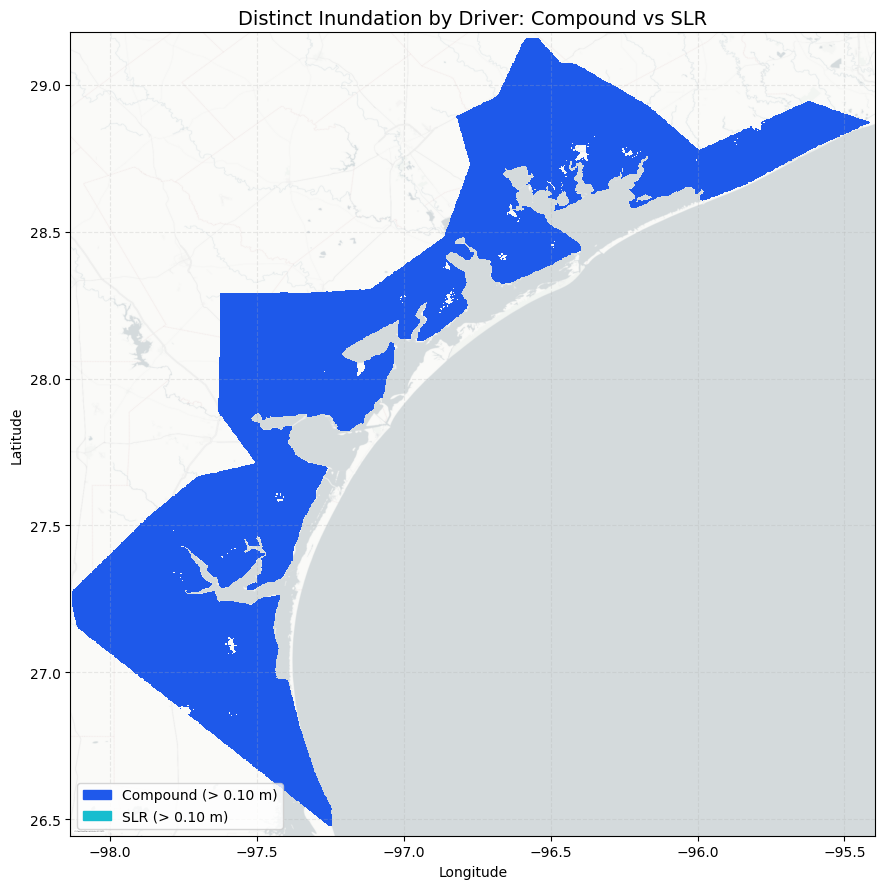

In [45]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import contextily as ctx

# ---- File paths ----
r_comp = r"D:\Phd Research\sim_depth_100yr.tif"                 # Compound
r_slr  = r"D:\Phd Research\inundation depth only SLR.tif"       # SLR

THRESH = 0.10          # depth threshold (m) for inundation
DST_CRS = "EPSG:4326"  # lat/long axes

def read_band_masked(path):
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True).astype("float32").filled(np.nan)
        prof = src.profile
    return arr, prof

def reproject_to(arr, src_prof, dst_transform, dst_crs, dst_shape):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform,       dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    return dst

# 1) Read both rasters
comp_arr, comp_prof = read_band_masked(r_comp)
slr_arr,  slr_prof  = read_band_masked(r_slr)

# 2) Build a common EPSG:4326 grid using the COMPOUND raster as reference
dst_transform, dst_w, dst_h = calculate_default_transform(
    comp_prof["crs"], DST_CRS, comp_prof["width"], comp_prof["height"],
    *array_bounds(comp_prof["height"], comp_prof["width"], comp_prof["transform"])
)
dst_shape = (dst_h, dst_w)

# 3) Reproject both to the common 4326 grid
comp_4326 = reproject_to(comp_arr, comp_prof, dst_transform, DST_CRS, dst_shape)
slr_4326  = reproject_to(slr_arr,  slr_prof,  dst_transform, DST_CRS, dst_shape)

# 4) Build inundation masks (> THRESH)
m_comp = np.isfinite(comp_4326) & (comp_4326 > THRESH)
m_slr  = np.isfinite(slr_4326)  & (slr_4326  > THRESH)

# 5) Categorical map with DISTINCT colors (no blending)
# codes: 0 background, 1=Compound, 2=SLR
cat = np.zeros(dst_shape, dtype=np.uint8)

# Lower priority first, higher priority last (so it overwrites overlaps).
cat[m_slr]  = 2           # SLR first (lower priority)
cat[m_comp] = 1           # Compound overwrites SLR in overlaps (higher priority)
# If you want SLR to dominate instead, swap the two lines above.

# 6) Plot with lon/lat axes + CartoDB Positron basemap
fig, ax = plt.subplots(figsize=(10.5, 9))
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)

# Fix view to data extent (so overlay aligns with basemap tiles)
ax.set_xlim(left, right)
ax.set_ylim(bottom, top)

# Basemap (will respect EPSG:4326 axes)
ctx.add_basemap(
    ax, crs=DST_CRS,
    source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=10, attribution_size=0
)

# Draw categorical raster ON TOP (background transparent)
colors = [
    (0,0,0,0),          # 0 background transparent
    (0.12,0.35,0.92,1), # 1 Compound (deep blue)
    (0.09,0.74,0.81,1), # 2 SLR (teal)
]
cmap = ListedColormap(colors)

ax.imshow(cat, cmap=cmap, interpolation='nearest',
          extent=[left, right, bottom, top], origin='upper')

# Legend (exactly two entries)
legend_patches = [
    mpatches.Patch(color=colors[1], label=f'Compound (> {THRESH:.2f} m)'),
    mpatches.Patch(color=colors[2], label=f'SLR (> {THRESH:.2f} m)'),
]
ax.legend(handles=legend_patches, loc='lower left', frameon=True)

ax.set_title("Distinct Inundation by Driver: Compound vs SLR", fontsize=14)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_aspect('equal'); ax.grid(alpha=0.25, linestyle='--')
plt.tight_layout(); plt.show()


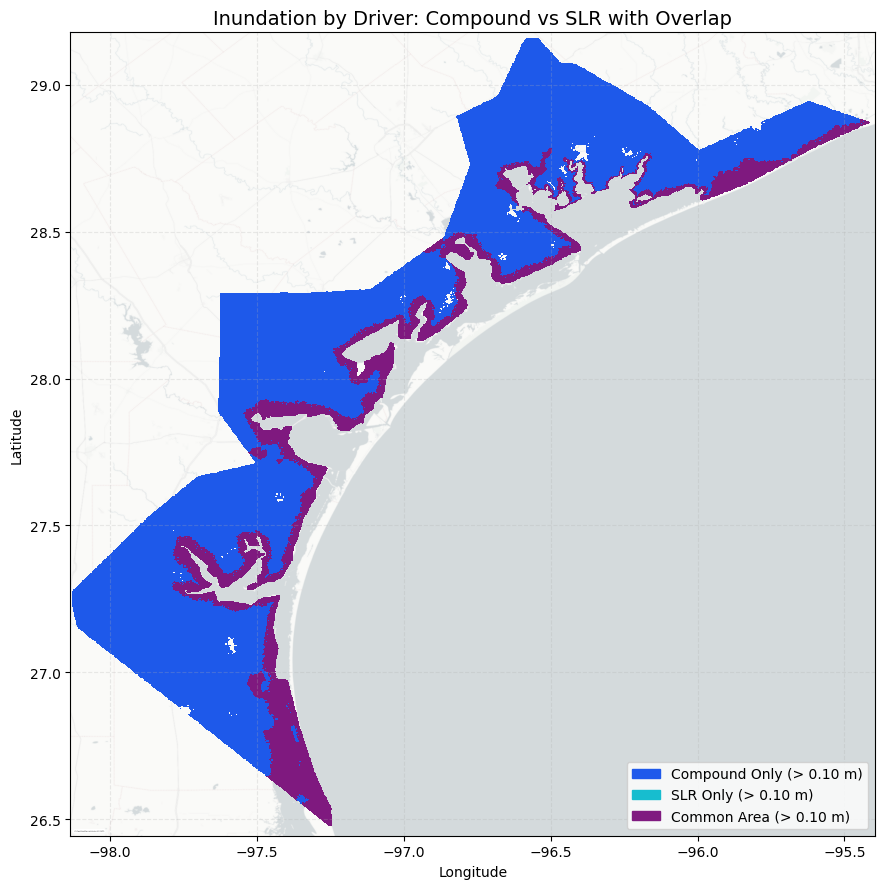

In [48]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import contextily as ctx

# ---- File paths ----
r_comp = r"D:\Phd Research\sim_depth_100yr.tif" # Compound
r_slr = r"D:\Phd Research\inundation depth only SLR.tif" # SLR

THRESH = 0.10 # depth threshold (m) for inundation
DST_CRS = "EPSG:4326" # lat/long axes

def read_band_masked(path):
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True).astype("float32").filled(np.nan)
        prof = src.profile
    return arr, prof

def reproject_to(arr, src_prof, dst_transform, dst_crs, dst_shape):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    return dst

# 1) Read both rasters
comp_arr, comp_prof = read_band_masked(r_comp)
slr_arr, slr_prof = read_band_masked(r_slr)

# 2) Build a common EPSG:4326 grid using the COMPOUND raster as reference
dst_transform, dst_w, dst_h = calculate_default_transform(
    comp_prof["crs"], DST_CRS, comp_prof["width"], comp_prof["height"],
    *array_bounds(comp_prof["height"], comp_prof["width"], comp_prof["transform"])
)
dst_shape = (dst_h, dst_w)

# 3) Reproject both to the common 4326 grid
comp_4326 = reproject_to(comp_arr, comp_prof, dst_transform, DST_CRS, dst_shape)
slr_4326 = reproject_to(slr_arr, slr_prof, dst_transform, DST_CRS, dst_shape)

# 4) Build inundation masks (> THRESH)
m_comp = np.isfinite(comp_4326) & (comp_4326 > THRESH)
m_slr = np.isfinite(slr_4326) & (slr_4326 > THRESH)

# 5) Categorical map with DISTINCT colors and common area
# codes: 0=background, 1=Compound-Only, 2=SLR-Only, 3=Common
cat = np.zeros(dst_shape, dtype=np.uint8)

# Find unique areas first
m_comp_only = m_comp & ~m_slr
m_slr_only = m_slr & ~m_comp
m_common = m_comp & m_slr

# Assign categories (order doesn't matter here since areas are non-overlapping)
cat[m_slr_only] = 2 # SLR-Only
cat[m_comp_only] = 1 # Compound-Only
cat[m_common] = 3 # Common Area (Highest priority)

# 6) Plot with lon/lat axes + CartoDB Positron basemap
fig, ax = plt.subplots(figsize=(10.5, 9))
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)

ax.set_xlim(left, right)
ax.set_ylim(bottom, top)

ctx.add_basemap(
    ax, crs=DST_CRS,
    source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=10, attribution_size=0
)

# Draw categorical raster ON TOP (background transparent)
colors = [
    (0,0,0,0), # 0 background transparent
    (0.12,0.35,0.92,1), # 1 Compound-Only (deep blue)
    (0.09,0.74,0.81,1), # 2 SLR-Only (teal)
    (0.5, 0.1, 0.5, 1) # 3 Common Area (purple)
]
cmap = ListedColormap(colors)

ax.imshow(cat, cmap=cmap, interpolation='nearest',
          extent=[left, right, bottom, top], origin='upper')

# Legend (exactly three entries)
legend_patches = [
    mpatches.Patch(color=colors[1], label=f'Compound Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=colors[2], label=f'SLR Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=colors[3], label=f'Common Area (> {THRESH:.2f} m)'),
]
ax.legend(handles=legend_patches, loc='lower right', frameon=True)

ax.set_title("Inundation by Driver: Compound vs SLR with Overlap", fontsize=14)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_aspect('equal'); ax.grid(alpha=0.25, linestyle='--')
plt.tight_layout(); plt.show()

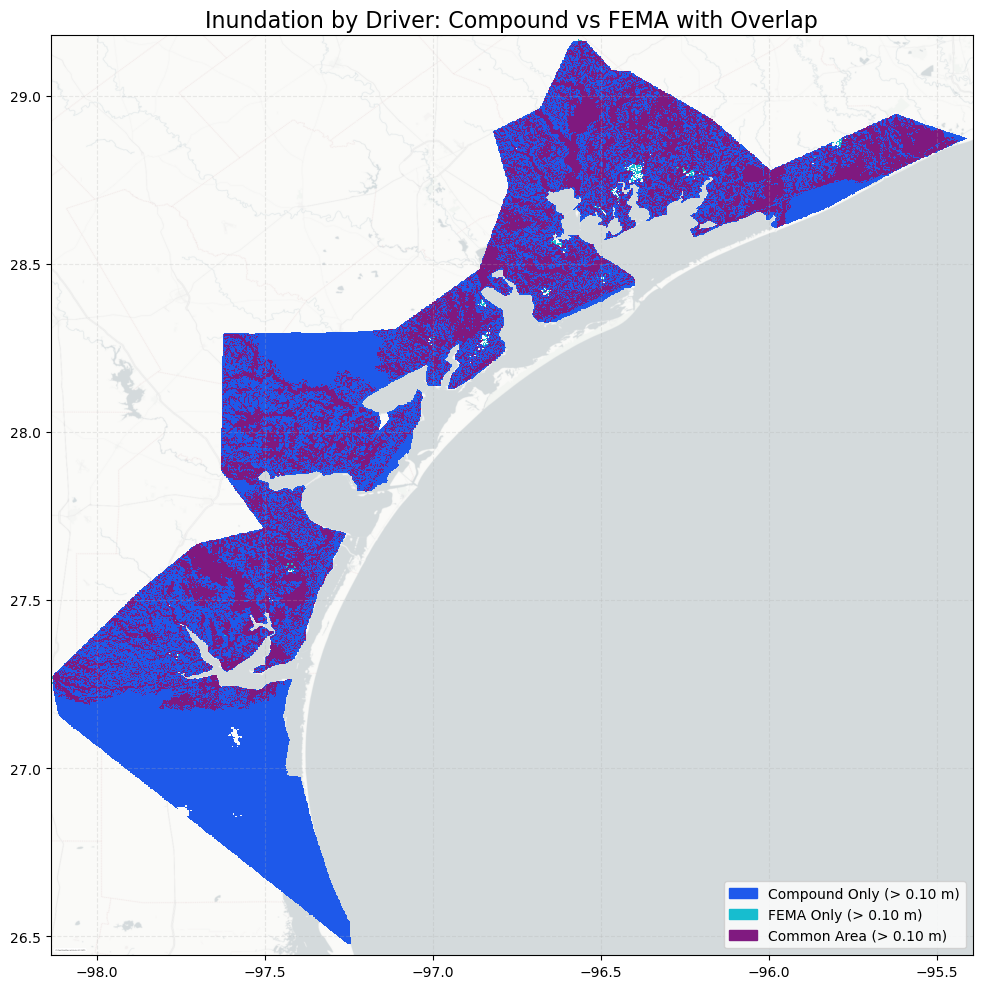

In [50]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import contextily as ctx

# ---- File paths ----
r_comp = r"D:\Phd Research\sim_depth_100yr.tif" # Compound
r_slr = r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif"

THRESH = 0.10 # depth threshold (m) for inundation
DST_CRS = "EPSG:4326" # lat/long axes

def read_band_masked(path):
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True).astype("float32").filled(np.nan)
        prof = src.profile
    return arr, prof

def reproject_to(arr, src_prof, dst_transform, dst_crs, dst_shape):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    return dst

# 1) Read both rasters
comp_arr, comp_prof = read_band_masked(r_comp)
slr_arr, slr_prof = read_band_masked(r_slr)

# 2) Build a common EPSG:4326 grid using the COMPOUND raster as reference
dst_transform, dst_w, dst_h = calculate_default_transform(
    comp_prof["crs"], DST_CRS, comp_prof["width"], comp_prof["height"],
    *array_bounds(comp_prof["height"], comp_prof["width"], comp_prof["transform"])
)
dst_shape = (dst_h, dst_w)

# 3) Reproject both to the common 4326 grid
comp_4326 = reproject_to(comp_arr, comp_prof, dst_transform, DST_CRS, dst_shape)
slr_4326 = reproject_to(slr_arr, slr_prof, dst_transform, DST_CRS, dst_shape)

# 4) Build inundation masks (> THRESH)
m_comp = np.isfinite(comp_4326) & (comp_4326 > THRESH)
m_slr = np.isfinite(slr_4326) & (slr_4326 > THRESH)

# 5) Categorical map with DISTINCT colors and common area
# codes: 0=background, 1=Compound-Only, 2=SLR-Only, 3=Common
cat = np.zeros(dst_shape, dtype=np.uint8)

# Find unique areas first
m_comp_only = m_comp & ~m_slr
m_slr_only = m_slr & ~m_comp
m_common = m_comp & m_slr

# Assign categories (order doesn't matter here since areas are non-overlapping)
cat[m_slr_only] = 2 # SLR-Only
cat[m_comp_only] = 1 # Compound-Only
cat[m_common] = 3 # Common Area (Highest priority)

# 6) Plot with lon/lat axes + CartoDB Positron basemap
fig, ax = plt.subplots(figsize=(10, 10))
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)

ax.set_xlim(left, right)
ax.set_ylim(bottom, top)

ctx.add_basemap(
    ax, crs=DST_CRS,
    source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=10, attribution_size=0
)

# Draw categorical raster ON TOP (background transparent)
colors = [
    (0,0,0,0), # 0 background transparent
    (0.12,0.35,0.92,1), # 1 Compound-Only (deep blue)
    (0.09,0.74,0.81,1), # 2 SLR-Only (teal)
    (0.5, 0.1, 0.5, 1) # 3 Common Area (purple)
]
cmap = ListedColormap(colors)

ax.imshow(cat, cmap=cmap, interpolation='nearest',
          extent=[left, right, bottom, top], origin='upper')

# Legend (exactly three entries)
legend_patches = [
    mpatches.Patch(color=colors[1], label=f'Compound Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=colors[2], label=f'FEMA Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=colors[3], label=f'Common Area (> {THRESH:.2f} m)'),
]
ax.legend(handles=legend_patches, loc='lower right', frameon=True)

ax.set_title("Inundation by Driver: Compound vs FEMA with Overlap", fontsize=16)
#ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_aspect('equal'); ax.grid(alpha=0.25, linestyle='--')
plt.tight_layout(); plt.show()

C:\Users\sahad2\AppData\Local\Temp\ipykernel_49436\2952442252.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


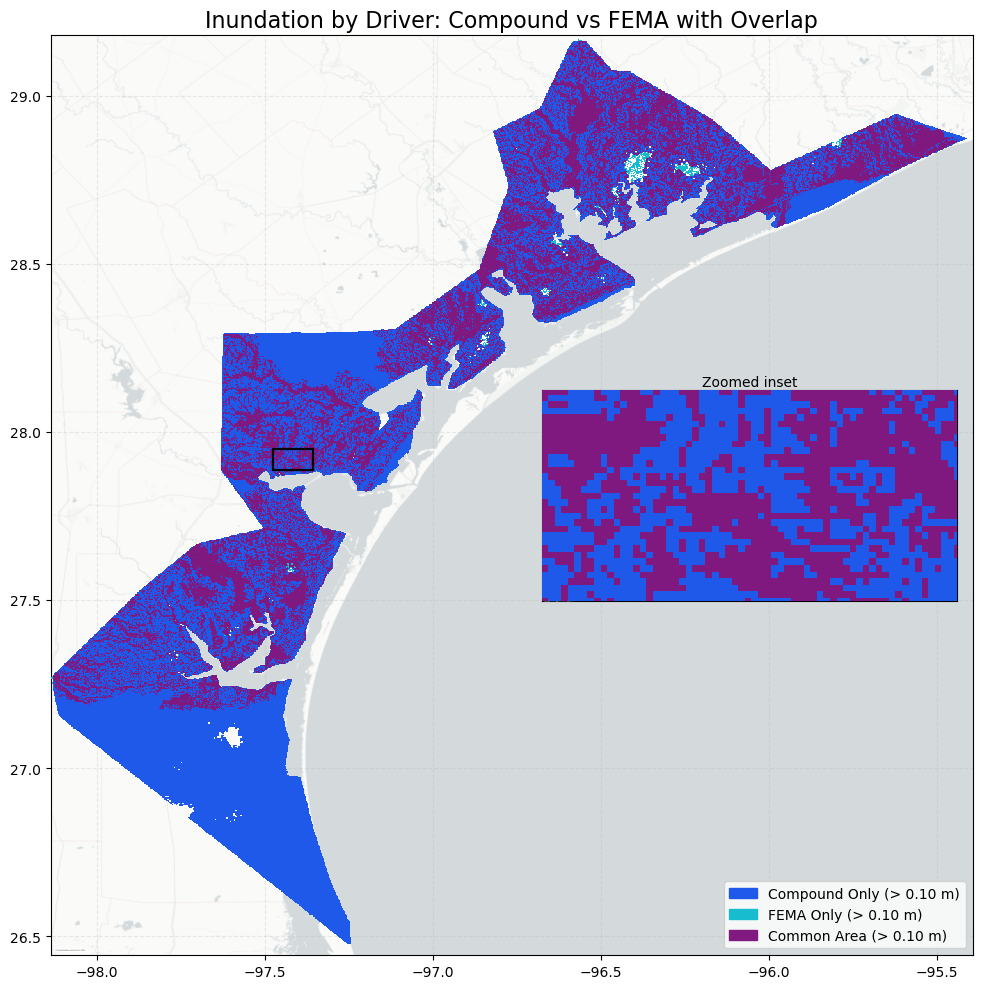

In [2]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle               # NEW
from mpl_toolkits.axes_grid1.inset_locator import inset_axes  # NEW
import contextily as ctx

# ---- File paths ----
r_comp = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"  # Compound
r_slr  = r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif"             # FEMA depth

THRESH   = 0.10        # depth threshold (m) for inundation
DST_CRS  = "EPSG:4326" # lat/long axes
INSET_BBOX = (-97.475853, 27.886425, -97.355347, 27.947706)  # (left, bottom, right, top)
INSET_SIZE = ("45%", "45%")   # inset size relative to main axes
INSET_LOC  = "center right"   # position of inset on main axes
INSET_ZOOM = 13               # basemap zoom for inset
MAIN_ZOOM  = 10               # basemap zoom for main map

def read_band_masked(path):
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True).astype("float32").filled(np.nan)
        prof = src.profile
    return arr, prof

def reproject_to(arr, src_prof, dst_transform, dst_crs, dst_shape):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    return dst

# 1) Read both rasters
comp_arr, comp_prof = read_band_masked(r_comp)
slr_arr,  slr_prof  = read_band_masked(r_slr)

# 2) Common EPSG:4326 grid using the COMPOUND raster as reference
dst_transform, dst_w, dst_h = calculate_default_transform(
    comp_prof["crs"], DST_CRS, comp_prof["width"], comp_prof["height"],
    *array_bounds(comp_prof["height"], comp_prof["width"], comp_prof["transform"])
)
dst_shape = (dst_h, dst_w)

# 3) Reproject both to the common 4326 grid
comp_4326 = reproject_to(comp_arr, comp_prof, dst_transform, DST_CRS, dst_shape)
slr_4326  = reproject_to(slr_arr,  slr_prof,  dst_transform, DST_CRS, dst_shape)

# 4) Build inundation masks (> THRESH)
m_comp = np.isfinite(comp_4326) & (comp_4326 > THRESH)
m_slr  = np.isfinite(slr_4326)  & (slr_4326  > THRESH)

# 5) Categorical map: 0=bg, 1=Compound-Only, 2=FEMA-Only, 3=Common
cat = np.zeros(dst_shape, dtype=np.uint8)
m_comp_only = m_comp & ~m_slr
m_slr_only  = m_slr  & ~m_comp
m_common    = m_comp &  m_slr
cat[m_slr_only]  = 2
cat[m_comp_only] = 1
cat[m_common]    = 3

# 6) Plot main map with basemap
fig, ax = plt.subplots(figsize=(10, 10))
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)

ax.set_xlim(left, right)
ax.set_ylim(bottom, top)

# Basemap for main map
ctx.add_basemap(
    ax, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=MAIN_ZOOM, attribution_size=0, zorder=1
)

# Overlay categorical raster
colors = [
    (0,0,0,0),             # 0 background transparent
    (0.12,0.35,0.92,1),    # 1 Compound-Only (deep blue)
    (0.09,0.74,0.81,1),    # 2 FEMA-Only (teal)
    (0.50,0.10,0.50,1)     # 3 Common (purple)
]
cmap = ListedColormap(colors)
ax.imshow(cat, cmap=cmap, interpolation='nearest',
          extent=[left, right, bottom, top], origin='upper', zorder=4)

# Legend
legend_patches = [
    mpatches.Patch(color=colors[1], label=f'Compound Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=colors[2], label=f'FEMA Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=colors[3], label=f'Common Area (> {THRESH:.2f} m)'),
]
ax.legend(handles=legend_patches, loc='lower right', frameon=True)

ax.set_title("Inundation by Driver: Compound vs FEMA with Overlap", fontsize=16)
ax.set_aspect('equal'); ax.grid(alpha=0.25, linestyle='--')

# 7) Inset map (center-right) over the given bbox
axins = inset_axes(ax, width=INSET_SIZE[0], height=INSET_SIZE[1],
                   loc=INSET_LOC, borderpad=1.1)

# Crop inset to bbox
lx, by, rx, ty = INSET_BBOX
axins.set_xlim(lx, rx)
axins.set_ylim(by, ty)

# Inset basemap (higher zoom)
ctx.add_basemap(
    axins, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=INSET_ZOOM, attribution_size=0, zorder=1
)

# Draw same categorical overlay in inset
axins.imshow(cat, cmap=cmap, interpolation='nearest',
             extent=[left, right, bottom, top], origin='upper', zorder=4)

# Tidy inset
axins.set_xticks([]); axins.set_yticks([])
axins.set_title("Zoomed inset", fontsize=10, pad=3)

# Rectangle on main map showing inset coverage
rect = Rectangle((lx, by), rx - lx, ty - by, fill=False, lw=1.6, ec="black", zorder=10)
ax.add_patch(rect)

plt.tight_layout()
plt.show()


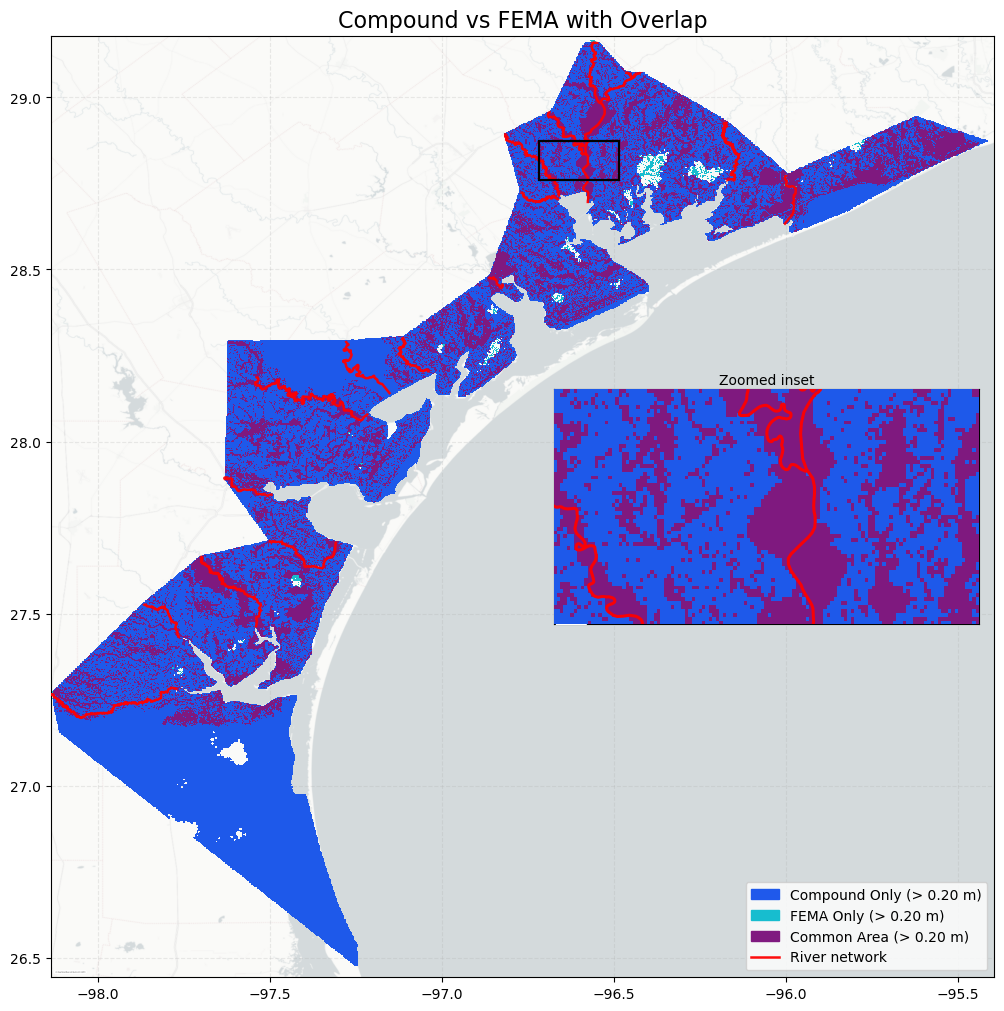

In [24]:
import os, zipfile
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines
import contextily as ctx

# ---- File paths ----
r_comp = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"  # Compound
r_slr  = r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif"             # FEMA depth
river_zip   = r"D:\Phd Research\1D HD Model\Shape file\River_Network_final.zip"
river_unzip = r"D:\Phd Research\1D HD Model\Shape file\unzipped_rivers"

# ---- Params ----
THRESH   = 0.2
DST_CRS  = "EPSG:4326"
INSET_BBOX = (-96.718140,28.759232,-96.484680,28.873539)  # (left, bottom, right, top)
INSET_SIZE = ("45%", "45%")
INSET_LOC  = "center right"
INSET_ZOOM = 13
MAIN_ZOOM  = 10

# Rivers (RED) on top
RIVER_COLOR = (1, 0, 0, 0.95)
RIVER_LW_MAIN  = 1.8
RIVER_LW_INSET = 2.2

def read_band_masked(path):
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True).astype("float32").filled(np.nan)
        prof = src.profile
    return arr, prof

def reproject_to(arr, src_prof, dst_transform, dst_crs, dst_shape):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    return dst

def read_rivers(zip_path, out_dir, target_crs=DST_CRS):
    if not os.path.isdir(out_dir) or not any(f.endswith(".shp") for f in os.listdir(out_dir)):
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)
    shp = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith(".shp")]
    if not shp:
        raise FileNotFoundError("No .shp found in unzipped river folder.")
    gdf = gpd.read_file(shp[0])
    if gdf.crs is None:
        raise ValueError("River shapefile has no CRS defined.")
    return gdf.to_crs(target_crs)

# 1) Read rasters
comp_arr, comp_prof = read_band_masked(r_comp)
slr_arr,  slr_prof  = read_band_masked(r_slr)

# 2) Common EPSG:4326 grid using the COMPOUND raster as reference
dst_transform, dst_w, dst_h = calculate_default_transform(
    comp_prof["crs"], DST_CRS, comp_prof["width"], comp_prof["height"],
    *array_bounds(comp_prof["height"], comp_prof["width"], comp_prof["transform"])
)
dst_shape = (dst_h, dst_w)

# 3) Reproject both to the common grid
comp_4326 = reproject_to(comp_arr, comp_prof, dst_transform, DST_CRS, dst_shape)
slr_4326  = reproject_to(slr_arr,  slr_prof,  dst_transform, DST_CRS, dst_shape)

# 4) Masks (> THRESH) and categorical map
m_comp = np.isfinite(comp_4326) & (comp_4326 > THRESH)
m_slr  = np.isfinite(slr_4326)  & (slr_4326  > THRESH)

cat = np.zeros(dst_shape, dtype=np.uint8)  # 0=bg, 1=Compound-Only, 2=FEMA-Only, 3=Common
cat[m_comp & ~m_slr] = 1
cat[m_slr & ~m_comp] = 2
cat[m_comp &  m_slr] = 3

# 5) Rivers (to plotting CRS)
gdf_rivers = read_rivers(river_zip, river_unzip, target_crs=DST_CRS)

# 6) Common extent
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)
extent = [left, right, bottom, top]

# 7) Plot (use constrained_layout to avoid tight_layout issues)
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)

# ---- MAIN AXIS ----
ax.set_xlim(left, right); ax.set_ylim(bottom, top)

# Basemap first (uses current axis limits)
ctx.add_basemap(ax, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=MAIN_ZOOM, attribution_size=0, zorder=1)

# Flood overlay (full image)
cmap = ListedColormap([
    (0,0,0,0),           # 0 background transparent
    (0.12,0.35,0.92,1),  # 1 Compound-Only (deep blue)
    (0.09,0.74,0.81,1),  # 2 FEMA-Only (teal)
    (0.50,0.10,0.50,1)   # 3 Common (purple)
])
ax.imshow(cat, cmap=cmap, interpolation='nearest', extent=extent, origin='upper', zorder=4)

# Rivers ON TOP (no clipping; axis limits will clip)
gdf_rivers.plot(ax=ax, color=RIVER_COLOR, linewidth=RIVER_LW_MAIN, zorder=6)

# Legend
legend_patches = [
    mpatches.Patch(color=(0.12,0.35,0.92,1), label=f'Compound Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=(0.09,0.74,0.81,1), label=f'FEMA Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=(0.50,0.10,0.50,1), label=f'Common Area (> {THRESH:.2f} m)'),
]
river_handle = mlines.Line2D([], [], color=RIVER_COLOR, linewidth=RIVER_LW_MAIN, label='River network')
ax.legend(handles=legend_patches + [river_handle], loc='lower right', frameon=True)

ax.set_title("Compound vs FEMA with Overlap", fontsize=16)
ax.set_aspect('equal'); ax.grid(alpha=0.25, linestyle='--')

# ---- INSET AXIS (exact zoom of main) ----
axins = inset_axes(ax, width=INSET_SIZE[0], height=INSET_SIZE[1], loc=INSET_LOC, borderpad=1.1)

# 1) Set limits to bbox BEFORE adding basemap so tiles match the view
lx, by, rx, ty = INSET_BBOX
axins.set_xlim(lx, rx); axins.set_ylim(by, ty)

# 2) Basemap (same source)
ctx.add_basemap(axins, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=INSET_ZOOM, attribution_size=0, zorder=1)

# 3) Draw EXACTLY the same full layers as main (same extent/origin/zorder)
axins.imshow(cat, cmap=cmap, interpolation='nearest', extent=extent, origin='upper', zorder=4)
gdf_rivers.plot(ax=axins, color=RIVER_COLOR, linewidth=RIVER_LW_INSET, zorder=6)

# 4) Clean inset and draw bbox on main
axins.set_xticks([]); axins.set_yticks([])
axins.set_title("Zoomed inset", fontsize=10, pad=3)
rect = Rectangle((lx, by), rx - lx, ty - by, fill=False, lw=1.6, ec="black", zorder=10)
ax.add_patch(rect)

plt.show()


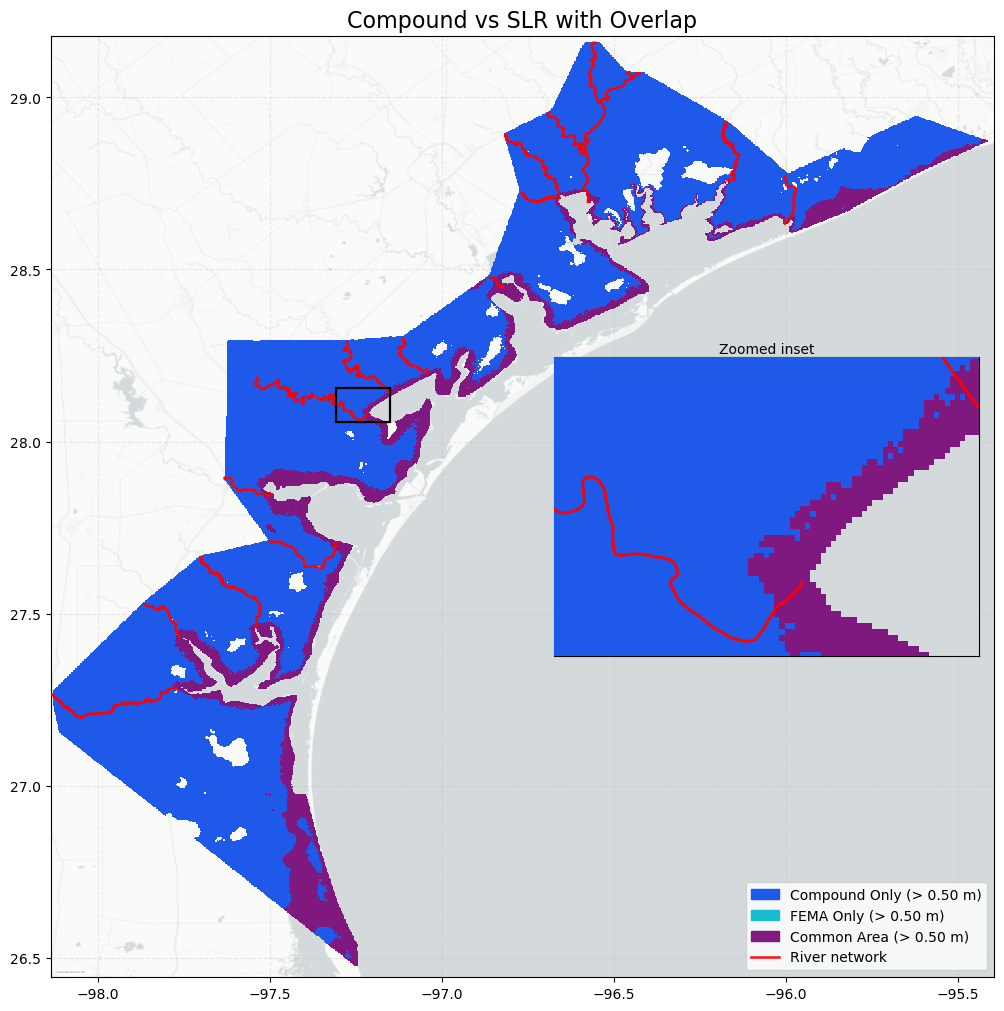

In [16]:
import os, zipfile
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines
import contextily as ctx

# ---- File paths ----
r_comp = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"  # Compound
r_slr  = r"D:\Phd Research\inundation depth only SLR.tif"             # SLR only depth
river_zip   = r"D:\Phd Research\1D HD Model\Shape file\River_Network_final.zip"
river_unzip = r"D:\Phd Research\1D HD Model\Shape file\unzipped_rivers"

# ---- Params ----
THRESH   = 0.5
DST_CRS  = "EPSG:4326"
INSET_BBOX = (-97.305908,28.057439,-97.149353,28.154347)  # (left, bottom, right, top)
INSET_SIZE = ("45%", "45%")
INSET_LOC  = "center right"
INSET_ZOOM = 13
MAIN_ZOOM  = 10

# Rivers (RED) on top
RIVER_COLOR = (1, 0, 0, 0.95)
RIVER_LW_MAIN  = 1.8
RIVER_LW_INSET = 2.2

def read_band_masked(path):
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True).astype("float32").filled(np.nan)
        prof = src.profile
    return arr, prof

def reproject_to(arr, src_prof, dst_transform, dst_crs, dst_shape):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    return dst

def read_rivers(zip_path, out_dir, target_crs=DST_CRS):
    if not os.path.isdir(out_dir) or not any(f.endswith(".shp") for f in os.listdir(out_dir)):
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)
    shp = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith(".shp")]
    if not shp:
        raise FileNotFoundError("No .shp found in unzipped river folder.")
    gdf = gpd.read_file(shp[0])
    if gdf.crs is None:
        raise ValueError("River shapefile has no CRS defined.")
    return gdf.to_crs(target_crs)

# 1) Read rasters
comp_arr, comp_prof = read_band_masked(r_comp)
slr_arr,  slr_prof  = read_band_masked(r_slr)

# 2) Common EPSG:4326 grid using the COMPOUND raster as reference
dst_transform, dst_w, dst_h = calculate_default_transform(
    comp_prof["crs"], DST_CRS, comp_prof["width"], comp_prof["height"],
    *array_bounds(comp_prof["height"], comp_prof["width"], comp_prof["transform"])
)
dst_shape = (dst_h, dst_w)

# 3) Reproject both to the common grid
comp_4326 = reproject_to(comp_arr, comp_prof, dst_transform, DST_CRS, dst_shape)
slr_4326  = reproject_to(slr_arr,  slr_prof,  dst_transform, DST_CRS, dst_shape)

# 4) Masks (> THRESH) and categorical map
m_comp = np.isfinite(comp_4326) & (comp_4326 > THRESH)
m_slr  = np.isfinite(slr_4326)  & (slr_4326  > THRESH)

cat = np.zeros(dst_shape, dtype=np.uint8)  # 0=bg, 1=Compound-Only, 2=FEMA-Only, 3=Common
cat[m_comp & ~m_slr] = 1
cat[m_slr & ~m_comp] = 2
cat[m_comp &  m_slr] = 3

# 5) Rivers (to plotting CRS)
gdf_rivers = read_rivers(river_zip, river_unzip, target_crs=DST_CRS)

# 6) Common extent
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)
extent = [left, right, bottom, top]

# 7) Plot (use constrained_layout to avoid tight_layout issues)
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)

# ---- MAIN AXIS ----
ax.set_xlim(left, right); ax.set_ylim(bottom, top)

# Basemap first (uses current axis limits)
ctx.add_basemap(ax, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=MAIN_ZOOM, attribution_size=0, zorder=1)

# Flood overlay (full image)
cmap = ListedColormap([
    (0,0,0,0),           # 0 background transparent
    (0.12,0.35,0.92,1),  # 1 Compound-Only (deep blue)
    (0.09,0.74,0.81,1),  # 2 FEMA-Only (teal)
    (0.50,0.10,0.50,1)   # 3 Common (purple)
])
ax.imshow(cat, cmap=cmap, interpolation='nearest', extent=extent, origin='upper', zorder=4)

# Rivers ON TOP (no clipping; axis limits will clip)
gdf_rivers.plot(ax=ax, color=RIVER_COLOR, linewidth=RIVER_LW_MAIN, zorder=6)

# Legend
legend_patches = [
    mpatches.Patch(color=(0.12,0.35,0.92,1), label=f'Compound Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=(0.09,0.74,0.81,1), label=f'FEMA Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=(0.50,0.10,0.50,1), label=f'Common Area (> {THRESH:.2f} m)'),
]
river_handle = mlines.Line2D([], [], color=RIVER_COLOR, linewidth=RIVER_LW_MAIN, label='River network')
ax.legend(handles=legend_patches + [river_handle], loc='lower right', frameon=True)

ax.set_title("Compound vs SLR with Overlap", fontsize=16)
ax.set_aspect('equal'); ax.grid(alpha=0.25, linestyle='--')

# ---- INSET AXIS (exact zoom of main) ----
axins = inset_axes(ax, width=INSET_SIZE[0], height=INSET_SIZE[1], loc=INSET_LOC, borderpad=1.1)

# 1) Set limits to bbox BEFORE adding basemap so tiles match the view
lx, by, rx, ty = INSET_BBOX
axins.set_xlim(lx, rx); axins.set_ylim(by, ty)

# 2) Basemap (same source)
ctx.add_basemap(axins, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=INSET_ZOOM, attribution_size=0, zorder=1)

# 3) Draw EXACTLY the same full layers as main (same extent/origin/zorder)
axins.imshow(cat, cmap=cmap, interpolation='nearest', extent=extent, origin='upper', zorder=4)
gdf_rivers.plot(ax=axins, color=RIVER_COLOR, linewidth=RIVER_LW_INSET, zorder=6)

# 4) Clean inset and draw bbox on main
axins.set_xticks([]); axins.set_yticks([])
axins.set_title("Zoomed inset", fontsize=10, pad=3)
rect = Rectangle((lx, by), rx - lx, ty - by, fill=False, lw=1.6, ec="black", zorder=10)
ax.add_patch(rect)

plt.show()


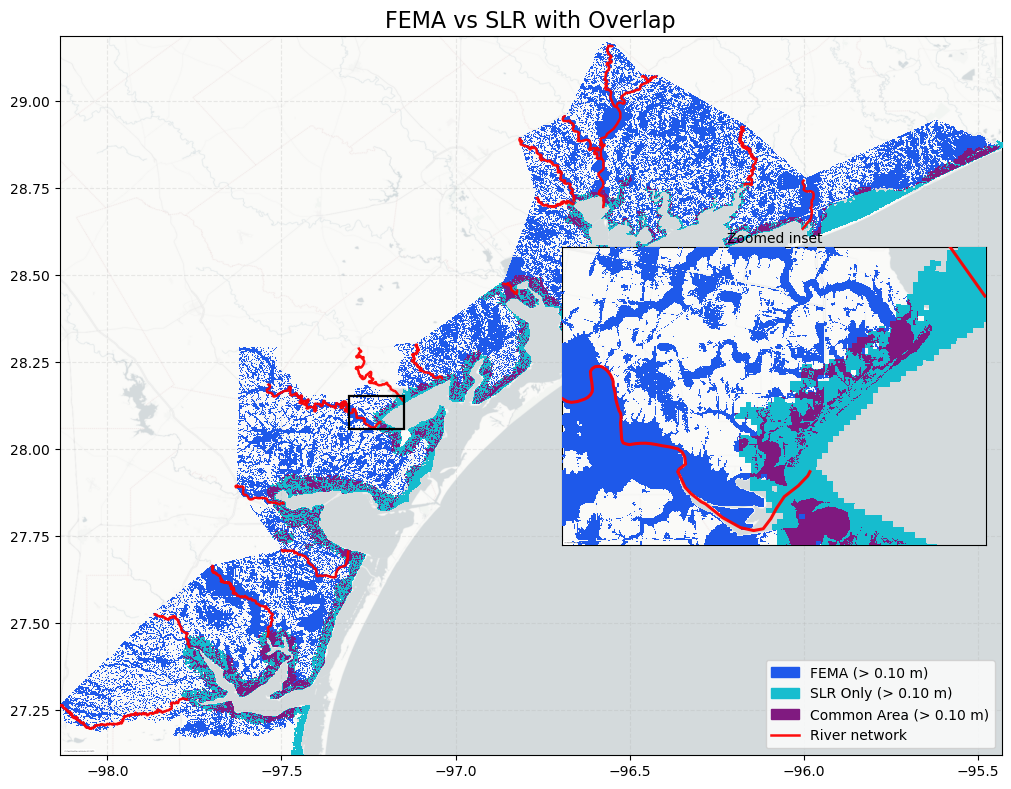

In [19]:
import os, zipfile
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines
import contextily as ctx

# ---- File paths ----
r_comp = r"D:\Phd Research\GIS\Raster\Fema_raster_100yr_25m.tif"    # Compound
r_slr  = r"D:\Phd Research\inundation depth only SLR.tif"             # SLR only depth
river_zip   = r"D:\Phd Research\1D HD Model\Shape file\River_Network_final.zip"
river_unzip = r"D:\Phd Research\1D HD Model\Shape file\unzipped_rivers"

# ---- Params ----
THRESH   = 0.1
DST_CRS  = "EPSG:4326"
INSET_BBOX = (-97.305908,28.057439,-97.149353,28.154347)  # (left, bottom, right, top)
INSET_SIZE = ("45%", "45%")
INSET_LOC  = "center right"
INSET_ZOOM = 13
MAIN_ZOOM  = 10

# Rivers (RED) on top
RIVER_COLOR = (1, 0, 0, 0.95)
RIVER_LW_MAIN  = 1.8
RIVER_LW_INSET = 2.2

def read_band_masked(path):
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True).astype("float32").filled(np.nan)
        prof = src.profile
    return arr, prof

def reproject_to(arr, src_prof, dst_transform, dst_crs, dst_shape):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    return dst

def read_rivers(zip_path, out_dir, target_crs=DST_CRS):
    if not os.path.isdir(out_dir) or not any(f.endswith(".shp") for f in os.listdir(out_dir)):
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)
    shp = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith(".shp")]
    if not shp:
        raise FileNotFoundError("No .shp found in unzipped river folder.")
    gdf = gpd.read_file(shp[0])
    if gdf.crs is None:
        raise ValueError("River shapefile has no CRS defined.")
    return gdf.to_crs(target_crs)

# 1) Read rasters
comp_arr, comp_prof = read_band_masked(r_comp)
slr_arr,  slr_prof  = read_band_masked(r_slr)

# 2) Common EPSG:4326 grid using the COMPOUND raster as reference
dst_transform, dst_w, dst_h = calculate_default_transform(
    comp_prof["crs"], DST_CRS, comp_prof["width"], comp_prof["height"],
    *array_bounds(comp_prof["height"], comp_prof["width"], comp_prof["transform"])
)
dst_shape = (dst_h, dst_w)

# 3) Reproject both to the common grid
comp_4326 = reproject_to(comp_arr, comp_prof, dst_transform, DST_CRS, dst_shape)
slr_4326  = reproject_to(slr_arr,  slr_prof,  dst_transform, DST_CRS, dst_shape)

# 4) Masks (> THRESH) and categorical map
m_comp = np.isfinite(comp_4326) & (comp_4326 > THRESH)
m_slr  = np.isfinite(slr_4326)  & (slr_4326  > THRESH)

cat = np.zeros(dst_shape, dtype=np.uint8)  # 0=bg, 1=Compound-Only, 2=FEMA-Only, 3=Common
cat[m_comp & ~m_slr] = 1
cat[m_slr & ~m_comp] = 2
cat[m_comp &  m_slr] = 3

# 5) Rivers (to plotting CRS)
gdf_rivers = read_rivers(river_zip, river_unzip, target_crs=DST_CRS)

# 6) Common extent
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)
extent = [left, right, bottom, top]

# 7) Plot (use constrained_layout to avoid tight_layout issues)
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)

# ---- MAIN AXIS ----
ax.set_xlim(left, right); ax.set_ylim(bottom, top)

# Basemap first (uses current axis limits)
ctx.add_basemap(ax, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=MAIN_ZOOM, attribution_size=0, zorder=1)

# Flood overlay (full image)
cmap = ListedColormap([
    (0,0,0,0),           # 0 background transparent
    (0.12,0.35,0.92,1),  # 1 Compound-Only (deep blue)
    (0.09,0.74,0.81,1),  # 2 FEMA-Only (teal)
    (0.50,0.10,0.50,1)   # 3 Common (purple)
])
ax.imshow(cat, cmap=cmap, interpolation='nearest', extent=extent, origin='upper', zorder=4)

# Rivers ON TOP (no clipping; axis limits will clip)
gdf_rivers.plot(ax=ax, color=RIVER_COLOR, linewidth=RIVER_LW_MAIN, zorder=6)

# Legend
legend_patches = [
    mpatches.Patch(color=(0.12,0.35,0.92,1), label=f'FEMA (> {THRESH:.2f} m)'),
    mpatches.Patch(color=(0.09,0.74,0.81,1), label=f'SLR Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=(0.50,0.10,0.50,1), label=f'Common Area (> {THRESH:.2f} m)'),
]
river_handle = mlines.Line2D([], [], color=RIVER_COLOR, linewidth=RIVER_LW_MAIN, label='River network')
ax.legend(handles=legend_patches + [river_handle], loc='lower right', frameon=True)

ax.set_title("FEMA vs SLR with Overlap", fontsize=16)
ax.set_aspect('equal'); ax.grid(alpha=0.25, linestyle='--')

# ---- INSET AXIS (exact zoom of main) ----
axins = inset_axes(ax, width=INSET_SIZE[0], height=INSET_SIZE[1], loc=INSET_LOC, borderpad=1.1)

# 1) Set limits to bbox BEFORE adding basemap so tiles match the view
lx, by, rx, ty = INSET_BBOX
axins.set_xlim(lx, rx); axins.set_ylim(by, ty)

# 2) Basemap (same source)
ctx.add_basemap(axins, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=INSET_ZOOM, attribution_size=0, zorder=1)

# 3) Draw EXACTLY the same full layers as main (same extent/origin/zorder)
axins.imshow(cat, cmap=cmap, interpolation='nearest', extent=extent, origin='upper', zorder=4)
gdf_rivers.plot(ax=axins, color=RIVER_COLOR, linewidth=RIVER_LW_INSET, zorder=6)

# 4) Clean inset and draw bbox on main
axins.set_xticks([]); axins.set_yticks([])
axins.set_title("Zoomed inset", fontsize=10, pad=3)
rect = Rectangle((lx, by), rx - lx, ty - by, fill=False, lw=1.6, ec="black", zorder=10)
ax.add_patch(rect)

plt.show()


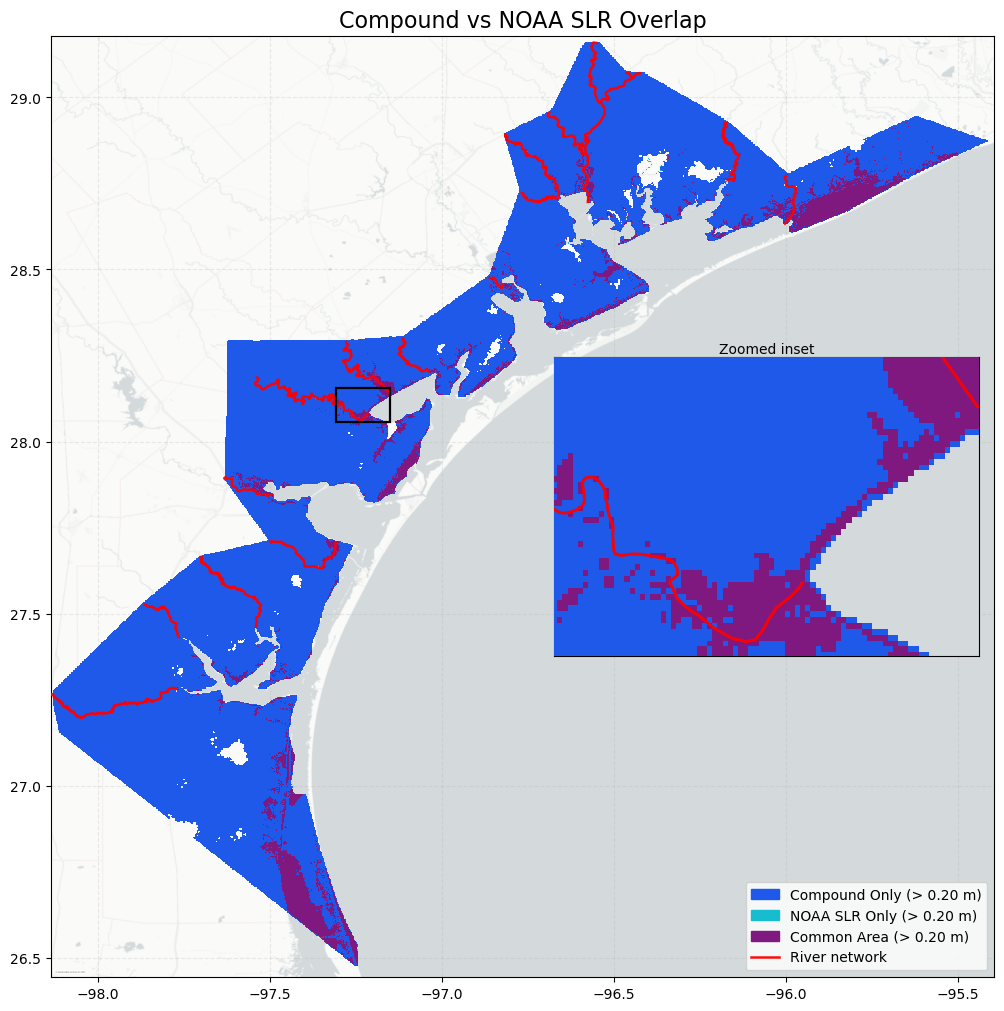

In [23]:
import os, zipfile
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines
import contextily as ctx

# ---- File paths ----
r_comp = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"  # Compound
r_slr  = r"C:\Users\sahad2\Research_data\SLR_Depth_Raster_NOAA\SLR_depth_3_5ft_tx_200m_UTM_m.tif"             # NOAA SLR only depth
river_zip   = r"D:\Phd Research\1D HD Model\Shape file\River_Network_final.zip"
river_unzip = r"D:\Phd Research\1D HD Model\Shape file\unzipped_rivers"

# ---- Params ----
THRESH   = 0.2
DST_CRS  = "EPSG:4326"
INSET_BBOX = (-97.305908,28.057439,-97.149353,28.154347)  # (left, bottom, right, top)
INSET_SIZE = ("45%", "45%")
INSET_LOC  = "center right"
INSET_ZOOM = 13
MAIN_ZOOM  = 10

# Rivers (RED) on top
RIVER_COLOR = (1, 0, 0, 0.95)
RIVER_LW_MAIN  = 1.8
RIVER_LW_INSET = 2.2

def read_band_masked(path):
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True).astype("float32").filled(np.nan)
        prof = src.profile
    return arr, prof

def reproject_to(arr, src_prof, dst_transform, dst_crs, dst_shape):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    return dst

def read_rivers(zip_path, out_dir, target_crs=DST_CRS):
    if not os.path.isdir(out_dir) or not any(f.endswith(".shp") for f in os.listdir(out_dir)):
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)
    shp = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith(".shp")]
    if not shp:
        raise FileNotFoundError("No .shp found in unzipped river folder.")
    gdf = gpd.read_file(shp[0])
    if gdf.crs is None:
        raise ValueError("River shapefile has no CRS defined.")
    return gdf.to_crs(target_crs)

# 1) Read rasters
comp_arr, comp_prof = read_band_masked(r_comp)
slr_arr,  slr_prof  = read_band_masked(r_slr)

# 2) Common EPSG:4326 grid using the COMPOUND raster as reference
dst_transform, dst_w, dst_h = calculate_default_transform(
    comp_prof["crs"], DST_CRS, comp_prof["width"], comp_prof["height"],
    *array_bounds(comp_prof["height"], comp_prof["width"], comp_prof["transform"])
)
dst_shape = (dst_h, dst_w)

# 3) Reproject both to the common grid
comp_4326 = reproject_to(comp_arr, comp_prof, dst_transform, DST_CRS, dst_shape)
slr_4326  = reproject_to(slr_arr,  slr_prof,  dst_transform, DST_CRS, dst_shape)

# 4) Masks (> THRESH) and categorical map
m_comp = np.isfinite(comp_4326) & (comp_4326 > THRESH)
m_slr  = np.isfinite(slr_4326)  & (slr_4326  > THRESH)

cat = np.zeros(dst_shape, dtype=np.uint8)  # 0=bg, 1=Compound-Only, 2=FEMA-Only, 3=Common
cat[m_comp & ~m_slr] = 1
cat[m_slr & ~m_comp] = 2
cat[m_comp &  m_slr] = 3

# 5) Rivers (to plotting CRS)
gdf_rivers = read_rivers(river_zip, river_unzip, target_crs=DST_CRS)

# 6) Common extent
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)
extent = [left, right, bottom, top]

# 7) Plot (use constrained_layout to avoid tight_layout issues)
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)

# ---- MAIN AXIS ----
ax.set_xlim(left, right); ax.set_ylim(bottom, top)

# Basemap first (uses current axis limits)
ctx.add_basemap(ax, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=MAIN_ZOOM, attribution_size=0, zorder=1)

# Flood overlay (full image)
cmap = ListedColormap([
    (0,0,0,0),           # 0 background transparent
    (0.12,0.35,0.92,1),  # 1 Compound-Only (deep blue)
    (0.09,0.74,0.81,1),  # 2 NOAA SLR (teal)
    (0.50,0.10,0.50,1)   # 3 Common (purple)
])
ax.imshow(cat, cmap=cmap, interpolation='nearest', extent=extent, origin='upper', zorder=4)

# Rivers ON TOP (no clipping; axis limits will clip)
gdf_rivers.plot(ax=ax, color=RIVER_COLOR, linewidth=RIVER_LW_MAIN, zorder=6)

# Legend
legend_patches = [
    mpatches.Patch(color=(0.12,0.35,0.92,1), label=f'Compound Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=(0.09,0.74,0.81,1), label=f'NOAA SLR Only (> {THRESH:.2f} m)'),
    mpatches.Patch(color=(0.50,0.10,0.50,1), label=f'Common Area (> {THRESH:.2f} m)'),
]
river_handle = mlines.Line2D([], [], color=RIVER_COLOR, linewidth=RIVER_LW_MAIN, label='River network')
ax.legend(handles=legend_patches + [river_handle], loc='lower right', frameon=True)

ax.set_title("Compound vs NOAA SLR Overlap", fontsize=16)
ax.set_aspect('equal'); ax.grid(alpha=0.25, linestyle='--')

# ---- INSET AXIS (exact zoom of main) ----
axins = inset_axes(ax, width=INSET_SIZE[0], height=INSET_SIZE[1], loc=INSET_LOC, borderpad=1.1)

# 1) Set limits to bbox BEFORE adding basemap so tiles match the view
lx, by, rx, ty = INSET_BBOX
axins.set_xlim(lx, rx); axins.set_ylim(by, ty)

# 2) Basemap (same source)
ctx.add_basemap(axins, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=INSET_ZOOM, attribution_size=0, zorder=1)

# 3) Draw EXACTLY the same full layers as main (same extent/origin/zorder)
axins.imshow(cat, cmap=cmap, interpolation='nearest', extent=extent, origin='upper', zorder=4)
gdf_rivers.plot(ax=axins, color=RIVER_COLOR, linewidth=RIVER_LW_INSET, zorder=6)

# 4) Clean inset and draw bbox on main
axins.set_xticks([]); axins.set_yticks([])
axins.set_title("Zoomed inset", fontsize=10, pad=3)
rect = Rectangle((lx, by), rx - lx, ty - by, fill=False, lw=1.6, ec="black", zorder=10)
ax.add_patch(rect)

plt.show()


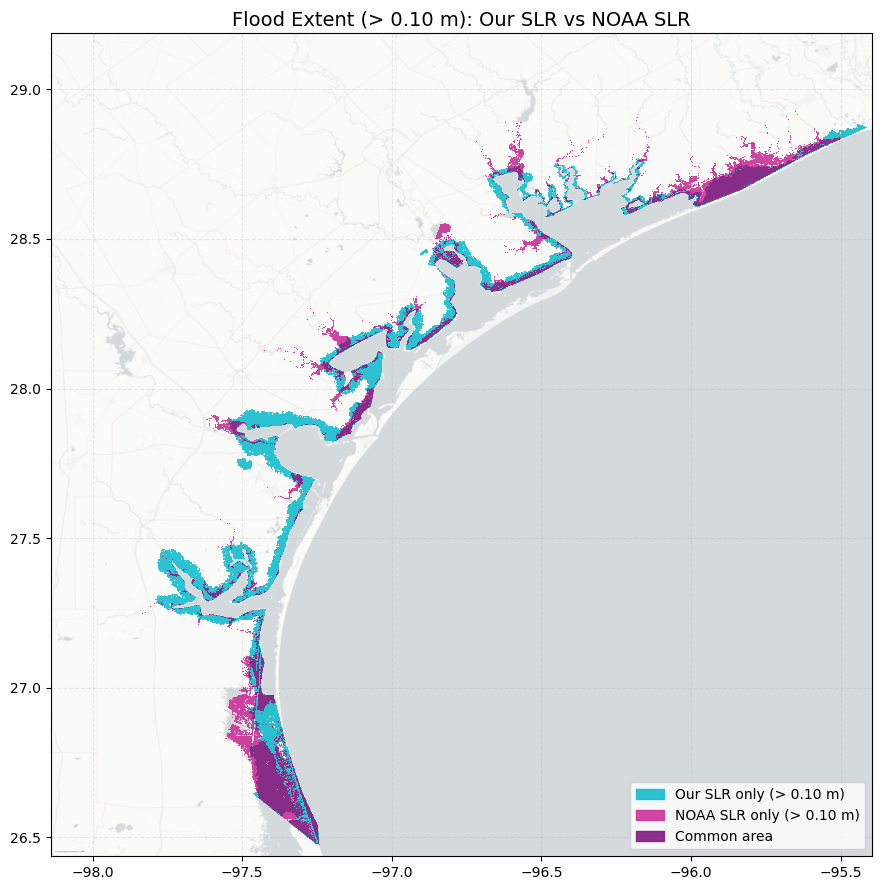

In [25]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin, array_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import contextily as ctx
import math

# ---------------- USER INPUTS ----------------
r_slr_ours = r"D:\Phd Research\Final_Raster\inundation only due ot SLR_wo_VLM_v1_stat.tif"
r_slr_noaa = r"C:\Users\sahad2\Research_data\SLR_Depth_Raster_NOAA\SLR_depth_3_5ft_tx_200m_UTM_m.tif"

THRESH       = 0.10        # inundation threshold (m)
TARGET_CRS   = "EPSG:4326" # plotting CRS (lon/lat)
TARGET_RES   = 0.0005      # deg/pixel (~45–55 m in TX). Increase if memory is tight.
BASEMAP_ZOOM = 10
# ---------------------------------------------

def read_depth(path):
    """Read depth band as float32 array with np.nan for nodata."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nod = src.nodata
        if nod is not None:
            arr = np.where(arr == nod, np.nan, arr)
        prof = src.profile
    return arr, prof

def union_bounds_in_target(profiles, target_crs):
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = array_bounds(h, w, p["transform"])
        l, b, r, t = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(l); ys_min.append(b); xs_max.append(r); ys_max.append(t)
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_dst_geo(left, bottom, right, top, res_deg):
    width  = int(math.ceil((right  - left) / res_deg))
    height = int(math.ceil((top    - bottom) / res_deg))
    transform = from_origin(left, top, res_deg, res_deg)
    return transform, width, height

def reproject_to(arr, src_prof, dst_transform, dst_crs, dst_shape):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    return dst

# 1) Read the two SLR rasters
slr_ours_arr, slr_ours_prof = read_depth(r_slr_ours)
slr_noaa_arr, slr_noaa_prof = read_depth(r_slr_noaa)

# 2) Common grid covering both (EPSG:4326)
left, bottom, right, top = union_bounds_in_target([slr_ours_prof, slr_noaa_prof], TARGET_CRS)
dst_transform, dst_w, dst_h = make_dst_geo(left, bottom, right, top, TARGET_RES)
dst_shape = (dst_h, dst_w)
extent = [left, right, bottom, top]

# 3) Reproject both to the common grid
slr_ours_4326 = reproject_to(slr_ours_arr, slr_ours_prof, dst_transform, TARGET_CRS, dst_shape)
slr_noaa_4326 = reproject_to(slr_noaa_arr, slr_noaa_prof, dst_transform, TARGET_CRS, dst_shape)

# 4) Binary inundation masks (> THRESH)
m_ours = np.isfinite(slr_ours_4326) & (slr_ours_4326 > THRESH)
m_noaa = np.isfinite(slr_noaa_4326) & (slr_noaa_4326 > THRESH)

# 5) Build categorical map (no compound here)
# codes: 0=bg, 1=Our SLR only, 2=NOAA SLR only, 3=Common
cat = np.zeros(dst_shape, dtype=np.uint8)
cat[( m_ours & ~m_noaa)] = 1
cat[(~m_ours &  m_noaa)] = 2
cat[( m_ours &  m_noaa)] = 3

# 6) Plot
fig, ax = plt.subplots(figsize=(10, 9))

ax.set_xlim(left, right); ax.set_ylim(bottom, top)
ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=BASEMAP_ZOOM, attribution_size=0, zorder=1)

# Colors: our SLR (teal), NOAA SLR (magenta), common (purple)
colors = [
    (0,0,0,0),            # 0 background
    (0.09, 0.74, 0.81, 0.90),  # 1 Our SLR only (teal)
    (0.80, 0.20, 0.60, 0.90),  # 2 NOAA SLR only (magenta)
    (0.50, 0.10, 0.50, 0.90),  # 3 Common (purple)
]
cmap = ListedColormap(colors)

ax.imshow(cat, cmap=cmap, interpolation='nearest', extent=extent, origin='upper', zorder=3)

# Legend
legend_patches = [
    mpatches.Patch(color=colors[1], label=f"Our SLR only (> {THRESH:.2f} m)"),
    mpatches.Patch(color=colors[2], label=f"NOAA SLR only (> {THRESH:.2f} m)"),
    mpatches.Patch(color=colors[3], label="Common area"),
]
ax.legend(handles=legend_patches, loc='lower right', frameon=True)

ax.set_title("Flood Extent (> {:.2f} m): Our SLR vs NOAA SLR".format(THRESH), fontsize=14)
ax.set_aspect('equal'); ax.grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()
